# 01 — Exploratory Data Analysis

**Question this project answers:** which single customer attribute best predicts a car
insurance claim, and is that answer actually better than guessing?

Two rules govern everything below.

**Everything here is computed on the training split only.** The validation set is for
model selection in Session 3, and the test set is not touched until Session 4. Choosing
which features look interesting by staring at all 10,000 rows is a subtle way of leaking
the test set into the modelling decisions.

**Every accuracy is read against the majority-class baseline.** The reference
implementation this project rebuilds reports 77.71% accuracy and never states the floor.
Establishing that floor is the main deliverable of this notebook.

In [1]:
import sys; sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config as cfg
from src.data import load_raw, split_data, majority_class_baseline
from src.plots import set_style, claim_rate_bar, save_fig

set_style()
pd.set_option("display.width", 140)

df = load_raw()
train, val, test = split_data(df)

print(f"full   {df.shape}")
print(f"train  {train.shape}")
print(f"val    {val.shape}")
print(f"test   {test.shape}   <- not touched until Session 4")

full   (10000, 18)
train  (7000, 18)
val    (1500, 18)
test   (1500, 18)   <- not touched until Session 4


## 1. The yardstick

`outcome` is imbalanced. That single fact determines how every later number must be read.

In [2]:
rate = train[cfg.TARGET].mean()
baseline = majority_class_baseline(train[cfg.TARGET])

print(f"claim rate (train):            {rate:.4f}")
print(f"majority-class baseline:       {baseline:.4f}")
print()
print("A model that predicts 'no claim' for every single customer is")
print(f"{baseline:.2%} accurate. The reference implementation reports 77.71%.")
print(f"The real signal on offer is {0.7771 - baseline:.2%}, not 77.71%.")

claim rate (train):            0.3133
majority-class baseline:       0.6867

A model that predicts 'no claim' for every single customer is
68.67% accurate. The reference implementation reports 77.71%.
The real signal on offer is 9.04%, not 77.71%.


In [3]:
# Stratification check: all three splits must carry the same claim rate,
# otherwise the baseline differs between sets and lift is not comparable.
pd.DataFrame({
    "n": [len(train), len(val), len(test)],
    "claim_rate": [s[cfg.TARGET].mean() for s in (train, val, test)],
    "baseline": [majority_class_baseline(s[cfg.TARGET]) for s in (train, val, test)],
}, index=["train", "val", "test"]).round(4)

,n,claim_rate,baseline
train,7000,0.3133,0.6867
val,1500,0.3133,0.6867
test,1500,0.3133,0.6867


## 2. Missing data

Only two columns have missing values. Whether that missingness is informative — whether
*the fact a value is absent* predicts a claim — is taken up properly in notebook 02. Here
we only establish the extent.

In [4]:
miss = train.isna().sum()
miss = miss[miss > 0].to_frame("n_missing")
miss["pct"] = (miss["n_missing"] / len(train) * 100).round(2)
miss

,n_missing,pct
credit_score,704,10.06
annual_mileage,677,9.67


## 3. Claim rate by feature

The chart below is the heart of the EDA. Each bar is a category's claim rate; the dashed
line is the 31.33% base rate. A feature is only predictive to the extent its bars depart
from that line.

findfont: Failed to find font weight semibold, now using 700.


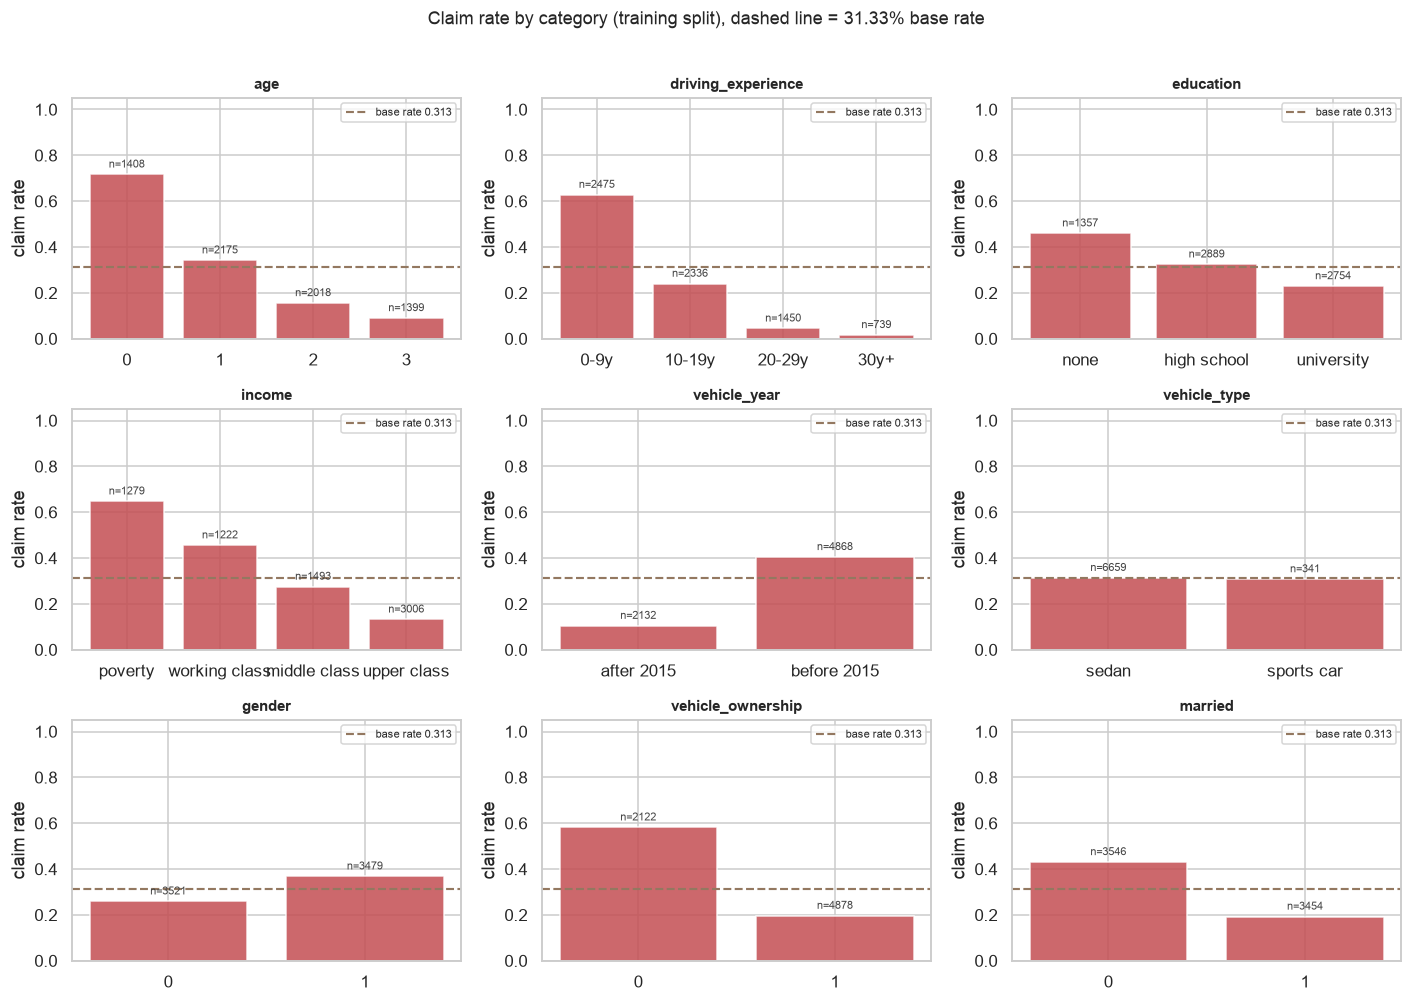

In [5]:
cat_cols = list(cfg.ORDINAL_LEVELS) + ["vehicle_year", "vehicle_type", "gender"] + cfg.BINARY

fig, axes = plt.subplots(3, 3, figsize=(13, 9))
for ax, col in zip(axes.ravel(), cat_cols):
    claim_rate_bar(train, col, ax, order=cfg.ORDINAL_LEVELS.get(col), baseline=rate)
for ax in axes.ravel()[len(cat_cols):]:
    ax.axis("off")
fig.suptitle("Claim rate by category (training split), dashed line = 31.33% base rate",
             fontsize=12, y=1.01)
fig.tight_layout()
save_fig(fig, "claim_rate_by_feature")
plt.show()

In [6]:
# The same information as a sorted table: how far does each feature spread the outcome?
rows = []
for col in cat_cols:
    g = train.groupby(col, observed=True)[cfg.TARGET].agg(["size", "mean"])
    rows.append({
        "feature": col,
        "n_levels": len(g),
        "min_rate": g["mean"].min(),
        "max_rate": g["mean"].max(),
        "spread": g["mean"].max() - g["mean"].min(),
    })
spread = pd.DataFrame(rows).sort_values("spread", ascending=False).reset_index(drop=True)
spread.round(3)

,feature,n_levels,min_rate,max_rate,spread
0,age,4,0.090,0.717,0.627
1,driving_experience,4,0.016,0.628,0.612
2,income,4,0.132,0.647,0.515
3,vehicle_ownership,2,0.196,0.582,0.386
4,vehicle_year,2,0.105,0.405,0.300
5,children,2,0.238,0.477,0.239
6,married,2,0.193,0.431,0.238
7,education,3,0.229,0.460,0.230
8,gender,2,0.259,0.368,0.109
9,vehicle_type,2,0.308,0.314,0.006


The result here is not the tidy one. `age` spreads the outcome **slightly wider** than
`driving_experience` — 0.627 against 0.612 — so the EDA does not, on its own, hand the
crown to the feature the reference implementation picked.

These two features are also not independent. Cramér's V between them is 0.668, and the
reason is structural rather than statistical: a driver aged 16-25 *cannot* have 30 years
of experience. The crosstab below is triangular by construction.

In [7]:
pd.crosstab(train["age"], train["driving_experience"]).reindex(
    columns=cfg.ORDINAL_LEVELS["driving_experience"])

driving_experience,0-9y,10-19y,20-29y,30y+
age,,,,
0,1408,0,0,0
1,478,1697,0,0
2,389,401,1228,0
3,200,238,222,739


So the two leading candidates encode overlapping information, and raw spread cannot
separate them. That is exactly why spread is a diagnostic here and not a verdict.

**Spread is not accuracy.** A feature's accuracy depends on where its predicted
probabilities fall relative to the decision threshold, not on how far apart its group
means are. A feature can top the spread table and still fail to beat 68.67%, because
moving a group from a 31% claim rate to a 45% claim rate shifts the probability without
ever crossing 0.5 — every customer still gets predicted "no claim."

Session 3 settles the ranking properly, on held-out data, with the parameter count made
visible. The reference's answer may well survive that test. It has not earned it yet.

## 4. `vehicle_type` — the canary

95% of customers drive a sedan, and the two categories have nearly identical claim rates.
This feature should carry no signal at all. It is worth keeping as a sanity check: if
`vehicle_type` ever posts an accuracy meaningfully above the baseline in Session 3, the
evaluation harness has a bug.

In [8]:
train.groupby("vehicle_type", observed=True)[cfg.TARGET].agg(
    n="size", claim_rate="mean"
).assign(share=lambda d: d["n"] / len(train)).round(3)

,n,claim_rate,share
vehicle_type,,,
sedan,6659,0.314,0.951
sports car,341,0.308,0.049


## 5. `postal_code` — an anomaly that changes how it must be modelled

`postal_code` is stored as an integer, so a dtype-driven pipeline treats it as a
*continuous* variable and fits a single slope across the values 10238, 21217, 32765 and
92101. Those numbers are labels; the arithmetic distance between two postal codes is
meaningless. This is the same defect as D4 in the plan, in a second disguise.

Treated correctly as a category, something unusual appears.

In [9]:
pc = train.groupby("postal_code", observed=True)[cfg.TARGET].agg(n="size", claim_rate="mean")
pc.round(3)

,n,claim_rate
postal_code,,
10238,4877,0.273
21217,75,1.000
32765,1702,0.376
92101,346,0.422


In [10]:
# Postal code 21217 in the full dataset, all splits.
sub = df[df.postal_code == 21217]
print(f"full dataset: n = {len(sub)}, claims = {sub[cfg.TARGET].sum()}, rate = {sub[cfg.TARGET].mean():.3f}")
for name, part in [("train", train), ("val", val), ("test", test)]:
    s = part[part.postal_code == 21217]
    print(f"  {name:5s} n = {len(s):3d}  claim rate = {s[cfg.TARGET].mean():.3f}")

full dataset: n = 120, claims = 120, rate = 1.000
  train n =  75  claim rate = 1.000
  val   n =  21  claim rate = 1.000
  test  n =  24  claim rate = 1.000


**Every one of the 120 customers in postal code 21217 filed a claim.** Not most — all of
them, in the training, validation and test splits alike.

Their other attributes are unremarkable: average credit score 0.54, average annual mileage
12,098, age distribution close to the overall one. Nothing in their risk profile explains
a 100% claim rate, which points to an artifact of how this dataset was generated rather
than a fact about drivers in Baltimore.

This matters mechanically, not just as trivia. A category in which the outcome never
varies causes **perfect separation**: the maximum-likelihood estimate for its coefficient
diverges, and the optimiser fails to converge.

In [11]:
import warnings
from statsmodels.formula.api import logit

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    m = logit("outcome ~ C(postal_code)", data=train).fit(disp=0)
    print(m.params.round(3).to_string())
    print()
    for w in caught:
        print(f"{w.category.__name__}: {w.message}")

Intercept                  -0.979
C(postal_code)[T.21217]    22.265
C(postal_code)[T.32765]     0.472
C(postal_code)[T.92101]     0.664



A coefficient of 22.3 on the log-odds scale is an odds ratio of roughly 4.7 billion. That
is not an estimate, it is the optimiser walking towards infinity and being stopped by an
iteration limit — hence the `ConvergenceWarning`.

Three consequences carried into the rest of the project:

1. `postal_code` must be modelled as a **category**, never as a number.
2. Any model including it needs a **penalised fit** to converge, and the resulting
   coefficient must not be interpreted as a real effect size.
3. Whatever accuracy it earns is **not a result worth shipping**. It reflects a
   deterministic rule baked into the data, and it would not survive contact with real
   customers. Session 3 reports its number and says exactly this alongside it.

## 6. Feature redundancy

If two features carry the same information, picking between them on a third decimal place
of accuracy is noise. Cramér's V measures association between categorical variables on a
0-1 scale.

findfont: Failed to find font weight semibold, now using 700.


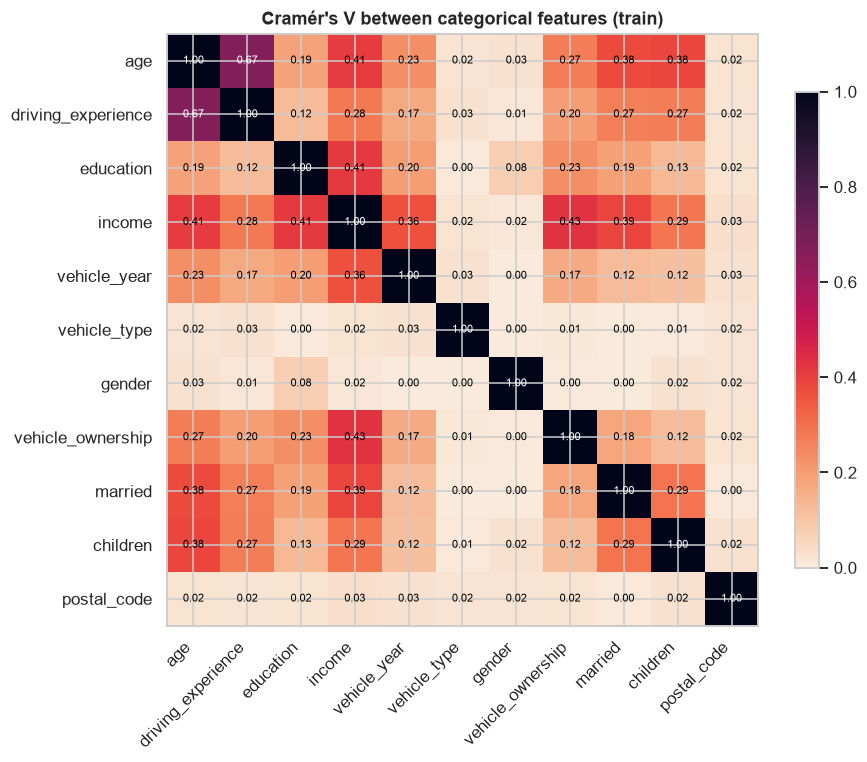

In [12]:
from scipy.stats import chi2_contingency

def cramers_v(a, b):
    ct = pd.crosstab(a, b)
    chi2 = chi2_contingency(ct)[0]
    n = ct.to_numpy().sum()
    r, k = ct.shape
    return np.sqrt((chi2 / n) / min(r - 1, k - 1))

assoc_cols = cat_cols + ["postal_code"]
V = pd.DataFrame(
    [[cramers_v(train[a], train[b]) for b in assoc_cols] for a in assoc_cols],
    index=assoc_cols, columns=assoc_cols,
)

fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(V, cmap="rocket_r", vmin=0, vmax=1)
ax.set_xticks(range(len(assoc_cols))); ax.set_xticklabels(assoc_cols, rotation=45, ha="right")
ax.set_yticks(range(len(assoc_cols))); ax.set_yticklabels(assoc_cols)
for i in range(len(assoc_cols)):
    for j in range(len(assoc_cols)):
        ax.text(j, i, f"{V.iloc[i, j]:.2f}", ha="center", va="center",
                fontsize=7, color="white" if V.iloc[i, j] > 0.5 else "black")
ax.set_title("Cramér's V between categorical features (train)")
fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout()
save_fig(fig, "feature_association")
plt.show()

In [13]:
# Strongest associations, excluding the diagonal.
pairs = [(a, b, V.loc[a, b]) for i, a in enumerate(assoc_cols) for b in assoc_cols[i+1:]]
pd.DataFrame(pairs, columns=["a", "b", "cramers_v"]).sort_values(
    "cramers_v", ascending=False).head(8).round(3).reset_index(drop=True)

,a,b,cramers_v
0,age,driving_experience,0.668
1,income,vehicle_ownership,0.427
2,education,income,0.414
3,age,income,0.409
4,income,married,0.389
5,age,children,0.383
6,age,married,0.378
7,income,vehicle_year,0.363


## 7. What carries into Session 2

- **The baseline is 68.67%.** Every accuracy reported in this project is stated next to
  it. Reproduced in `data/processed/baseline.csv`.
- **`driving_experience` spreads the outcome furthest** (0.628 to 0.019, monotone). The
  reference's conclusion looks sound; its evidence is what needs rebuilding.
- **`postal_code` must be categorical and penalised**, and its accuracy carries a health
  warning rather than a recommendation.
- **`vehicle_type` is the canary.** It should not beat the baseline.
- Missingness in `credit_score` (9.8%) and `annual_mileage` (9.6%) is quantified but not
  yet explained. Notebook 02 tests whether it is informative before imputing it away.

In [14]:
cfg.DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
pd.DataFrame([{
    "split": name,
    "n": len(part),
    "claim_rate": part[cfg.TARGET].mean(),
    "majority_class_baseline": majority_class_baseline(part[cfg.TARGET]),
} for name, part in [("train", train), ("val", val), ("test", test)]]
).to_csv(cfg.DATA_PROCESSED / "baseline.csv", index=False)

spread.to_csv(cfg.DATA_PROCESSED / "eda_feature_spread.csv", index=False)
print("wrote baseline.csv and eda_feature_spread.csv")

wrote baseline.csv and eda_feature_spread.csv
